In [28]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from numpy.linalg import pinv

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [29]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("../data/final/gmm_anomaly_detection_dataset.csv")

print("Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)

df.head()

Dataset Loaded Successfully

Dataset Shape:
(7516, 86)


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,...,Operational_Complexity_Level,Flight_Operational_Score,Flight_Operational_Priority,Smart_Alert_Priority,Information_Filter_Level,Decision_Support_Recommendation,GMM_Cluster,GMM_Log_Likelihood,GMM_Anomaly_Score,GMM_Anomaly_Label
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,...,Medium,6,Low,Low,Background Monitoring,Background Monitoring,0,-0.413259,24.597643,Normal
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,...,Medium,8,Medium,Medium,Standard Monitoring,Routine Monitoring,9,10.915888,13.268496,Normal
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,...,Medium,9,Medium,Medium,Standard Monitoring,Routine Monitoring,7,14.991280,9.193104,Normal
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,...,Medium,8,Medium,Medium,Standard Monitoring,Routine Monitoring,15,2.057020,22.127363,Normal
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,...,Medium,9,Medium,Medium,Standard Monitoring,Routine Monitoring,7,14.705517,9.478866,Normal


In [30]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\n")
print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 86 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   icao24                           7516 non-null   str    
 1   callsign                         7500 non-null   str    
 2   origin_country                   7516 non-null   str    
 3   time_position                    7516 non-null   float64
 4   last_constant                    7516 non-null   int64  
 5   longitude                        7516 non-null   float64
 6   latitude                         7516 non-null   float64
 7   baro_altitude                    7516 non-null   float64
 8   on_ground                        7516 non-null   bool   
 9   velocity                         7516 non-null   float64
 10  true_track                       7516 non-null   float64
 11  vertical_rate                    7516 non-null   float64
 12  geo_altitud

In [31]:
# ============================================================
# 4. MISSING VALUE ANALYSIS
# ============================================================

missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)

})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
squawk,4286,57.03
YEAR MFR,3255,43.31
Aircraft_Age,3255,43.31
AIR WORTH DATE,3201,42.59
ENG MFR MDL,3201,42.59
CERTIFICATION,3189,42.43
EXPIRATION DATE,3055,40.65
CERT ISSUE DATE,3055,40.65
SERIAL NUMBER,3049,40.57
N-NUMBER,3049,40.57


In [32]:
# ============================================================
# 5. STATISTICAL SUMMARY
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_position,7516.0,1.767745e+09,1.705541e+02,1.767739e+09,1.767745e+09,1.767745e+09,1.767745e+09,1.767745e+09
last_constant,7516.0,1.767745e+09,5.981213e+01,1.767745e+09,1.767745e+09,1.767745e+09,1.767745e+09,1.767745e+09
longitude,7516.0,-4.450562e+01,8.941508e+01,-1.753822e+02,-1.011478e+02,-8.330000e+01,1.023060e+01,1.775601e+02
latitude,7516.0,2.980902e+01,2.081991e+01,-4.684410e+01,2.871983e+01,3.494110e+01,4.049770e+01,6.990220e+01
baro_altitude,7516.0,6.789515e+03,4.176789e+03,-6.858000e+01,2.223135e+03,7.924800e+03,1.066038e+04,1.493520e+04
velocity,7516.0,1.560886e+02,8.889909e+01,0.000000e+00,6.791000e+01,1.832500e+02,2.277800e+02,7.435400e+02
true_track,7516.0,1.825430e+02,1.028934e+02,0.000000e+00,9.122500e+01,1.850000e+02,2.711500e+02,3.598400e+02
vertical_rate,7516.0,-2.933914e-01,4.587985e+00,-2.503000e+01,-6.500000e-01,0.000000e+00,0.000000e+00,2.308000e+01
geo_altitude,7516.0,6.903362e+03,4.226026e+03,-4.572000e+01,2.286000e+03,8.042910e+03,1.064514e+04,2.238756e+04
squawk,3230.0,3.484993e+03,2.147629e+03,7.000000e+00,1.573250e+03,3.214000e+03,5.338000e+03,7.774000e+03


In [33]:
# ============================================================
# 6. FEATURE SELECTION
# ============================================================

elm_features = [

    "latitude",
    "longitude",
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "vertical_rate",
    "true_track",
    "distance_to_airport_km",
    "Operational_Complexity_Index",
    "on_ground"

]

X = df[elm_features].copy()

print("Selected Features")

print("\nShape:", X.shape)

X.head()

Selected Features

Shape: (7516, 10)


,latitude,longitude,velocity,baro_altitude,geo_altitude,vertical_rate,true_track,distance_to_airport_km,Operational_Complexity_Index,on_ground
0,25.4425,52.7391,257.34,9608.82,9829.80,5.20,119.59,115.199726,7,False
1,38.1463,-84.9380,73.38,571.50,487.68,0.33,12.96,31.518443,6,False
2,34.0962,-102.0238,196.90,10363.20,10683.24,0.00,291.13,51.550924,8,False
3,-35.8060,174.5408,56.90,624.84,670.56,0.65,165.34,16.487628,6,False
4,37.4696,-102.7402,200.08,10972.80,11155.68,0.00,327.49,66.500547,8,False


In [34]:
# ============================================================
# 7. STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

print("Scaled Data Shape:", X_scaled.shape)

Feature Scaling Completed
Scaled Data Shape: (7516, 10)


In [35]:
# ============================================================
# 8. BUILD ELM AUTOENCODER
# ============================================================

class ELMAutoencoder:
    
    def __init__(self, input_size, hidden_size):
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Randomly initialize input weights
        self.input_weights = np.random.randn(
            self.input_size,
            self.hidden_size
        )
        
        # Randomly initialize hidden biases
        self.bias = np.random.randn(
            self.hidden_size
        )
        
        self.output_weights = None

    # --------------------------------------------------------
    # Sigmoid Activation Function
    # --------------------------------------------------------
    
    def sigmoid(self, x):
        
        return 1 / (1 + np.exp(-x))

    # --------------------------------------------------------
    # Train Autoencoder
    # --------------------------------------------------------
    
    def fit(self, X):
        
        # Hidden Layer Output Matrix (H)
        H = self.sigmoid(
            np.dot(X, self.input_weights) + self.bias
        )
        
        # Moore-Penrose Pseudo Inverse
        H_pinv = pinv(H)
        
        # Calculate Output Weights (Beta)
        self.output_weights = np.dot(H_pinv, X)

    # --------------------------------------------------------
    # Reconstruct Input
    # --------------------------------------------------------
    
    def reconstruct(self, X):
        
        H = self.sigmoid(
            np.dot(X, self.input_weights) + self.bias
        )
        
        X_reconstructed = np.dot(
            H,
            self.output_weights
        )
        
        return X_reconstructed

print("ELM Autoencoder Class Created Successfully")

ELM Autoencoder Class Created Successfully


In [36]:
# ============================================================
# 9. HIDDEN NEURON OPTIMIZATION
# ============================================================

hidden_neurons = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50,
    60,
    70
]

optimization_results = []

print("Starting Hidden Neuron Optimization...\n")

for neurons in hidden_neurons:

    errors = []

    for run in range(5):

        elm = ELMAutoencoder(
            input_size=X_scaled.shape[1],
            hidden_size=neurons
        )

        elm.fit(X_scaled)

        reconstructed = elm.reconstruct(X_scaled)

        mse = np.mean(
            np.square(X_scaled - reconstructed)
        )

        errors.append(mse)

    avg_error = np.mean(errors)

    optimization_results.append([neurons, avg_error])

    print(f"Hidden Neurons = {neurons:2d} | Average Error = {avg_error:.6f}")

Starting Hidden Neuron Optimization...

Hidden Neurons =  5 | Average Error = 0.531565
Hidden Neurons = 10 | Average Error = 0.251298
Hidden Neurons = 15 | Average Error = 0.121085
Hidden Neurons = 20 | Average Error = 0.080671
Hidden Neurons = 25 | Average Error = 0.058587
Hidden Neurons = 30 | Average Error = 0.044703
Hidden Neurons = 35 | Average Error = 0.036404
Hidden Neurons = 40 | Average Error = 0.032894
Hidden Neurons = 45 | Average Error = 0.029432
Hidden Neurons = 50 | Average Error = 0.026317
Hidden Neurons = 60 | Average Error = 0.022063
Hidden Neurons = 70 | Average Error = 0.017191


In [37]:
# ============================================================
# 9.1 OPTIMIZATION RESULTS
# ============================================================

optimization_df = pd.DataFrame(

    optimization_results,

    columns=[
        "Hidden_Neurons",
        "Average_Reconstruction_Error"
    ]

)

optimization_df

,Hidden_Neurons,Average_Reconstruction_Error
0,5,0.531565
1,10,0.251298
2,15,0.121085
3,20,0.080671
4,25,0.058587
5,30,0.044703
6,35,0.036404
7,40,0.032894
8,45,0.029432
9,50,0.026317


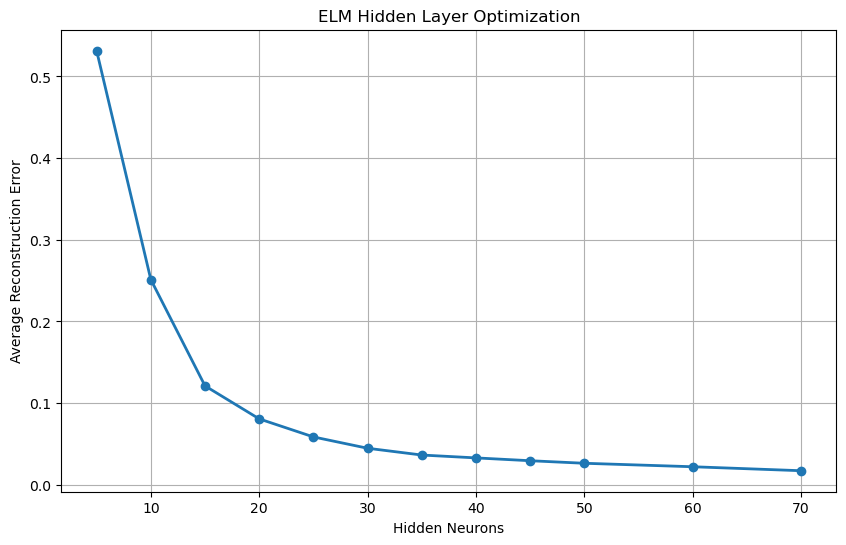

In [38]:
# ============================================================
# 9.2 VISUALIZE OPTIMIZATION
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    optimization_df["Hidden_Neurons"],
    optimization_df["Average_Reconstruction_Error"],
    marker="o",
    linewidth=2
)

plt.title("ELM Hidden Layer Optimization")

plt.xlabel("Hidden Neurons")

plt.ylabel("Average Reconstruction Error")

plt.grid(True)

plt.show()

In [39]:
# ============================================================
# 9.3 SELECT BEST HIDDEN SIZE
# ============================================================

best_hidden = optimization_df.loc[
    optimization_df["Average_Reconstruction_Error"].idxmin(),
    "Hidden_Neurons"
]

print(f"\nOptimal Hidden Neurons : {best_hidden}")
print(f"Optimal Hidden Neurons : {best_hidden}")

print(
    "Selected because it produced the lowest average reconstruction error."
)


Optimal Hidden Neurons : 70
Optimal Hidden Neurons : 70
Selected because it produced the lowest average reconstruction error.


In [40]:
# ============================================================
# 10. INITIALIZE FINAL ELM AUTOENCODER
# ============================================================

input_size = X_scaled.shape[1]

hidden_size = best_hidden

elm = ELMAutoencoder(
    input_size=input_size,
    hidden_size=hidden_size
)

print("Final ELM Initialized Successfully")

print(f"Input Neurons : {input_size}")
print(f"Hidden Neurons: {hidden_size}")

Final ELM Initialized Successfully
Input Neurons : 10
Hidden Neurons: 70


In [41]:
# ============================================================
# 11. TRAIN ELM AUTOENCODER
# ============================================================

elm.fit(X_scaled)

print("ELM Autoencoder Trained Successfully")

ELM Autoencoder Trained Successfully


In [42]:
# ============================================================
# 12. RECONSTRUCT FLIGHT DATA
# ============================================================

X_reconstructed = elm.reconstruct(X_scaled)

print("Flight Data Reconstructed Successfully")

print("\nOriginal Shape      :", X_scaled.shape)
print("Reconstructed Shape :", X_reconstructed.shape)

mse = np.mean(
    np.square(X_scaled - X_reconstructed)
)

print(f"Overall Reconstruction MSE : {mse:.6f}")

Flight Data Reconstructed Successfully

Original Shape      : (7516, 10)
Reconstructed Shape : (7516, 10)
Overall Reconstruction MSE : 0.017461


In [43]:
# ============================================================
# 13. CALCULATE RECONSTRUCTION ERROR
# ============================================================

reconstruction_error = np.mean(
    np.square(X_scaled - X_reconstructed),
    axis=1
)

df["ELM_Reconstruction_Error"] = reconstruction_error

print("Reconstruction Error Calculated Successfully")

print("\nReconstruction Error Statistics")
print(df["ELM_Reconstruction_Error"].describe())

Reconstruction Error Calculated Successfully

Reconstruction Error Statistics
count    7516.000000
mean        0.017461
std         0.040174
min         0.000329
25%         0.004562
50%         0.009046
75%         0.019274
max         1.670845
Name: ELM_Reconstruction_Error, dtype: float64


In [44]:
# ============================================================
# 14. GENERATE ELM ANOMALY SCORE
# ============================================================

df["ELM_Anomaly_Score"] = df["ELM_Reconstruction_Error"]

print("ELM Anomaly Score Generated Successfully")

print("\nELM Anomaly Score Statistics")
print(df["ELM_Anomaly_Score"].describe())

ELM Anomaly Score Generated Successfully

ELM Anomaly Score Statistics
count    7516.000000
mean        0.017461
std         0.040174
min         0.000329
25%         0.004562
50%         0.009046
75%         0.019274
max         1.670845
Name: ELM_Anomaly_Score, dtype: float64


In [45]:
# ============================================================
# 15. DETERMINE ANOMALY THRESHOLD
# ============================================================

threshold = df["ELM_Anomaly_Score"].quantile(0.95)

print("ELM Anomaly Threshold")

print(f"\n95th Percentile Threshold : {threshold:.6f}")

ELM Anomaly Threshold

95th Percentile Threshold : 0.052762


In [46]:
# ============================================================
# 16. LABEL ANOMALIES
# ============================================================

df["ELM_Anomaly_Label"] = np.where(
    df["ELM_Anomaly_Score"] >= threshold,
    "Anomaly",
    "Normal"
)

print("Anomaly Labels Assigned Successfully")

print("\nAnomaly Distribution")

print(df["ELM_Anomaly_Label"].value_counts())

print(
    round(
        df["ELM_Anomaly_Label"]
        .value_counts(normalize=True)
        *100,
        2
    )
)

Anomaly Labels Assigned Successfully

Anomaly Distribution
ELM_Anomaly_Label
Normal     7140
Anomaly     376
Name: count, dtype: int64
ELM_Anomaly_Label
Normal     95.0
Anomaly     5.0
Name: proportion, dtype: float64


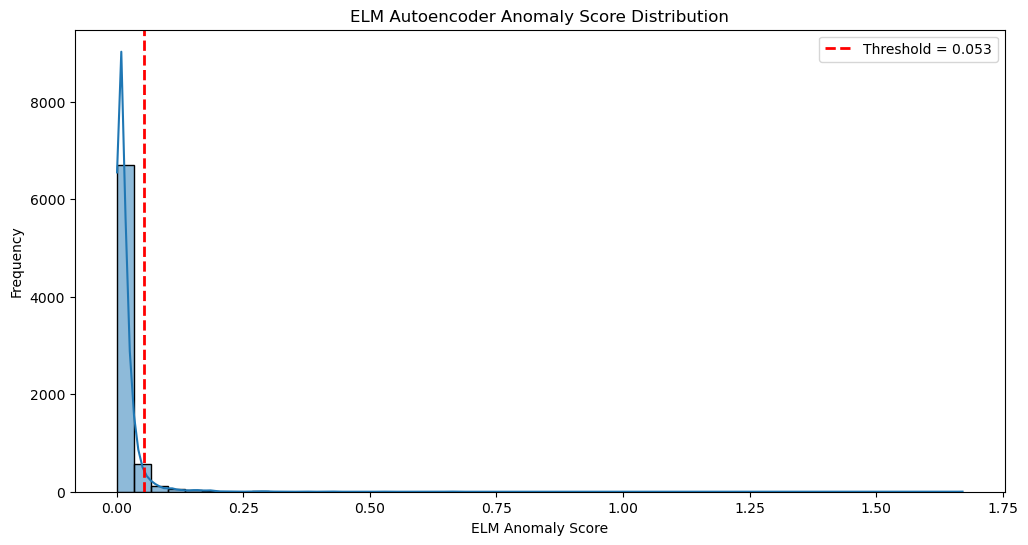

In [47]:
# ============================================================
# 17. VISUALIZE ELM ANOMALY SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df["ELM_Anomaly_Score"],
    bins=50,
    kde=True
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.3f}"
)

plt.title("ELM Autoencoder Anomaly Score Distribution")
plt.xlabel("ELM Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [48]:
# ============================================================
# 17. SAVE FINAL DATASET
# ============================================================

output_path = "../data/final/elm_anomaly_detection_dataset.csv"

df.to_csv(
    output_path,
    index=False
)

print("Dataset Saved Successfully")

print(output_path)

Dataset Saved Successfully
../data/final/elm_anomaly_detection_dataset.csv
